In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)
n = 100000

In [3]:
data = pd.DataFrame({
    "Customer_ID": np.arange(1, n+1),
    "Age": np.random.randint(18, 70, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Tenure": np.random.randint(0, 11, n),
    "Balance": np.random.uniform(0, 200000, n),
    "CreditScore": np.random.randint(300, 901, n),
    "EstimatedSalary": np.random.uniform(10000, 150000, n),
    "NumOfProducts": np.random.randint(1, 5, n),
    "IsActiveMember": np.random.choice(["Yes", "No"], n)
})


In [4]:
data["Churn"] = (
    (data["IsActiveMember"] == "No").astype(int) +
    (data["Balance"] > 100000).astype(int) +
    (data["NumOfProducts"] == 1).astype(int)
)

data["Churn"] = (data["Churn"] > 1).astype(int)

print(data.head())

   Customer_ID  Age  Gender  Tenure        Balance  CreditScore  \
0            1   56  Female       6   47344.336290          785   
1            2   69  Female       5  130807.362430          344   
2            3   46    Male       6   31507.247262          698   
3            4   32    Male       9   63594.102401          587   
4            5   60    Male       2  194871.165004          367   

   EstimatedSalary  NumOfProducts IsActiveMember  Churn  
0     19668.024908              3             No      0  
1     68917.797976              1             No      1  
2    125374.728326              4             No      0  
3    115246.270813              3             No      0  
4     17668.837550              1             No      1  


In [5]:
print(data.isnull().sum())

data["Gender"] = data["Gender"].map({"Male": 0, "Female": 1})
data["IsActiveMember"] = data["IsActiveMember"].map({"No": 0, "Yes": 1})

print(data.dtypes)

Customer_ID        0
Age                0
Gender             0
Tenure             0
Balance            0
CreditScore        0
EstimatedSalary    0
NumOfProducts      0
IsActiveMember     0
Churn              0
dtype: int64
Customer_ID          int64
Age                  int64
Gender               int64
Tenure               int64
Balance            float64
CreditScore          int64
EstimatedSalary    float64
NumOfProducts        int64
IsActiveMember       int64
Churn                int64
dtype: object


In [6]:
print(data.describe())

print("Mean:\n", data.mean())
print("Median:\n", data.median())
print("Mode:\n", data.mode().iloc[0])
print("Standard Deviation:\n", data.std())

         Customer_ID            Age         Gender         Tenure  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean    50000.500000      43.500270       0.498800       4.990560   
std     28867.657797      14.970933       0.500001       3.163813   
min         1.000000      18.000000       0.000000       0.000000   
25%     25000.750000      31.000000       0.000000       2.000000   
50%     50000.500000      43.000000       0.000000       5.000000   
75%     75000.250000      56.000000       1.000000       8.000000   
max    100000.000000      69.000000       1.000000      10.000000   

             Balance    CreditScore  EstimatedSalary  NumOfProducts  \
count  100000.000000  100000.000000    100000.000000  100000.000000   
mean   100212.336124     599.419450     80022.239950       2.497740   
std     57799.058934     173.255646     40416.250750       1.117545   
min         0.459637     300.000000     10000.467517       1.000000   
25%     50043.671439   

Churn
0    62306
1    37694
Name: count, dtype: int64


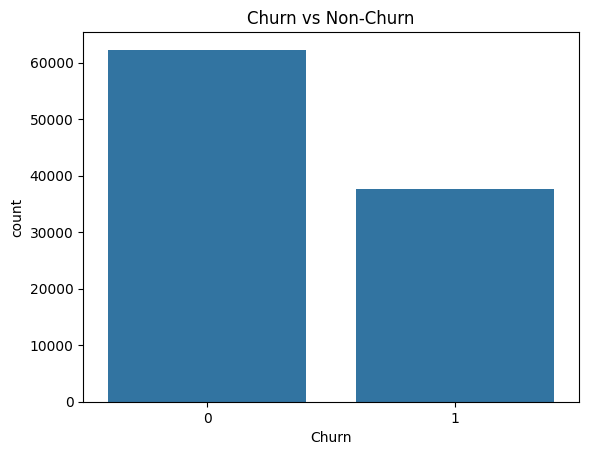

In [7]:
churn_counts = data["Churn"].value_counts()
print(churn_counts)

sns.countplot(x="Churn", data=data)
plt.title("Churn vs Non-Churn")
plt.show()

In [8]:
data["AgeGroup"] = pd.cut(data["Age"], bins=[18,30,40,50,60,70])

print(data.groupby("AgeGroup")["Churn"].mean())

print(data.groupby("Gender")["Churn"].mean())

print(data.groupby("IsActiveMember")["Churn"].mean())

print(data.groupby("NumOfProducts")["Churn"].mean())

AgeGroup
(18, 30]    0.373186
(30, 40]    0.383009
(40, 50]    0.377670
(50, 60]    0.377208
(60, 70]    0.373748
Name: Churn, dtype: float64
Gender
0    0.377334
1    0.376544
Name: Churn, dtype: float64
IsActiveMember
0    0.62629
1    0.12672
Name: Churn, dtype: float64
NumOfProducts
1    0.753724
2    0.251117
3    0.252691
4    0.249478
Name: Churn, dtype: float64


/tmp/ipykernel_7635/2240881754.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data.groupby("AgeGroup")["Churn"].mean())


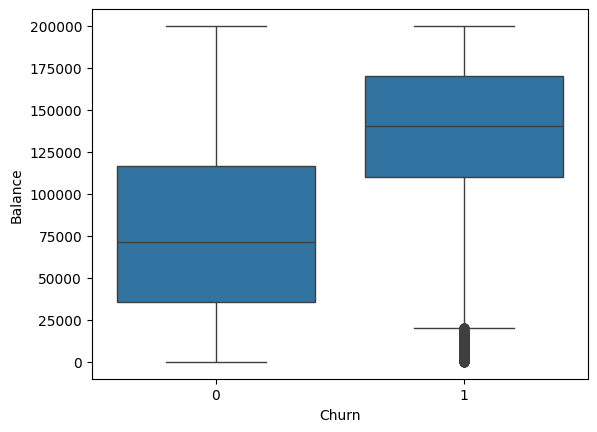

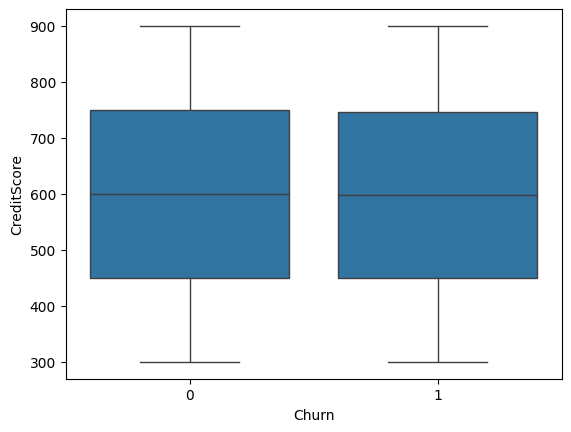

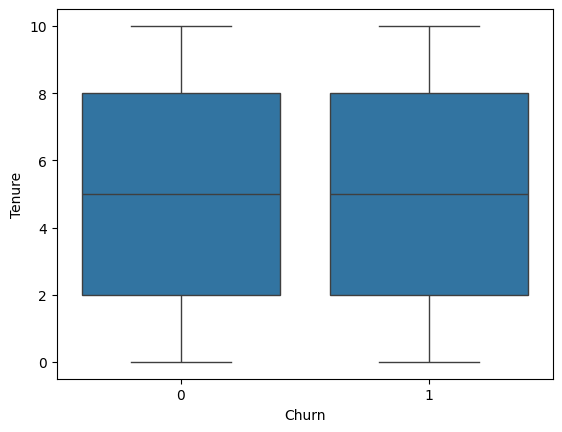

In [9]:
sns.boxplot(x="Churn", y="Balance", data=data)
plt.show()

sns.boxplot(x="Churn", y="CreditScore", data=data)
plt.show()

sns.boxplot(x="Churn", y="Tenure", data=data)
plt.show()

Histogram


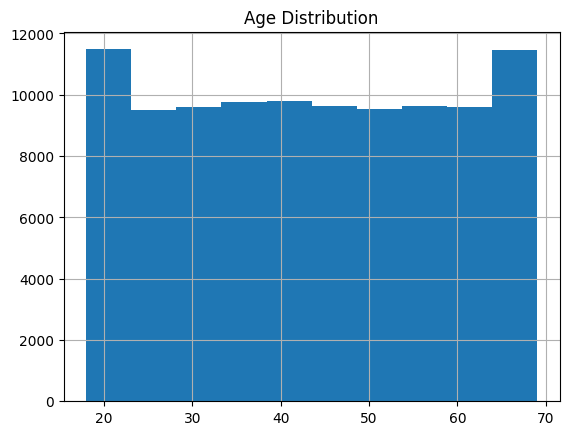

In [10]:
data["Age"].hist()
plt.title("Age Distribution")
plt.show()

Pie Chart

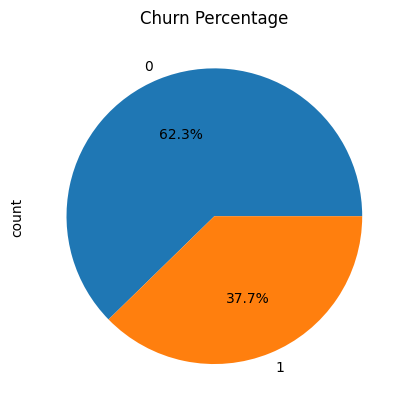

In [11]:
data["Churn"].value_counts().plot.pie(autopct="%1.1f%%")
plt.title("Churn Percentage")
plt.show()

Scatter Plot

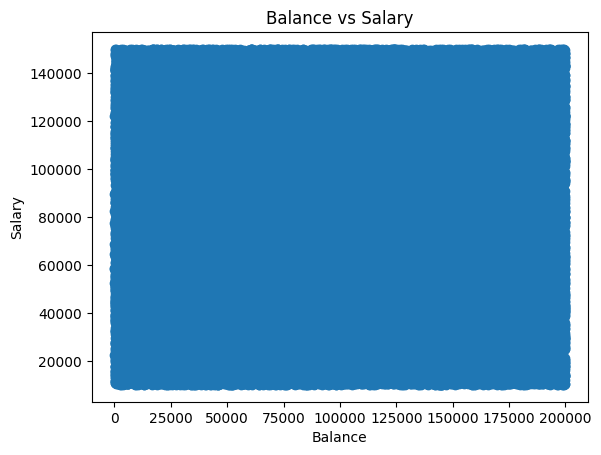

In [12]:
plt.scatter(data["Balance"], data["EstimatedSalary"])
plt.xlabel("Balance")
plt.ylabel("Salary")
plt.title("Balance vs Salary")
plt.show()

Heatmap

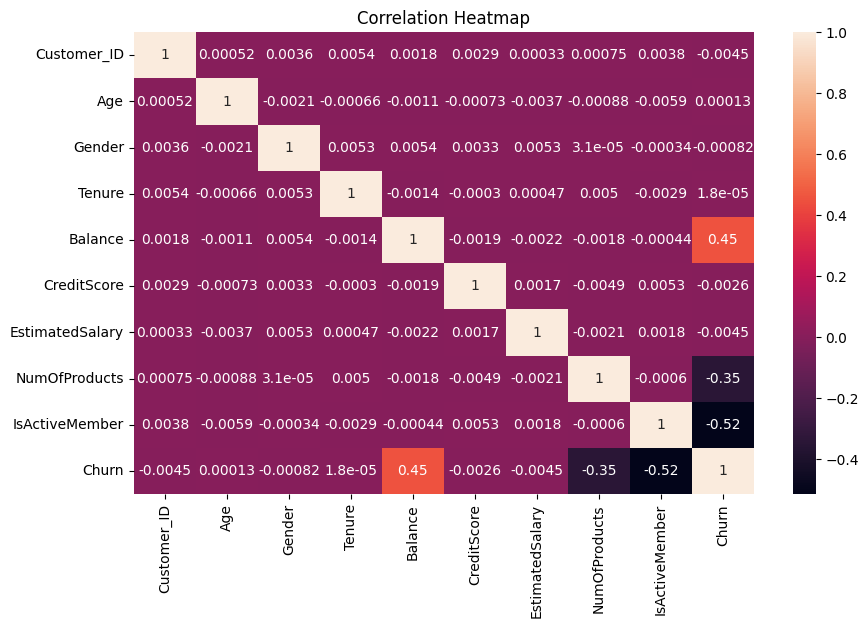

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(data.drop("AgeGroup", axis=1).corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [15]:
print("Insights:")
print("- Inactive customers churn more")
print("- Customers with low products churn more")
print("- High balance customers show higher churn tendency")

Insights:
- Inactive customers churn more
- Customers with low products churn more
- High balance customers show higher churn tendency
